## Custom Drift Compensation Draft



In [198]:
import math
import random
import numpy as np

""" Helper functions to conpute the drift exponent nu"""
def mu_nu(g_t:float)->float:
    g_t = max(g_t, 0.1e-9)
    return min(max(-0.0155*math.log(g_t)+0.0244, 0.049),0.1)

def sigma_nu(g_t:float)->float:
    g_t = max(g_t, 0.1e-9)
    return min(max(-0.0125*math.log(g_t)-0.0059, 0.008),0.045)



def g_drift(g_t:float, t_c:float, t:float)->float:
    """
    A function to model the drift of the conductance value. For simplicity, suppose the g_prog = g_t passed as argument

    Args:
        g_t (float): the target conductance value
        t_c (float): the time at which we know the conductance value g_prog
        t (float): the time at which we want to know the conductance value

    Returns:
        float: the conductance value at time t
    
    """
    mu = mu_nu(g_t)
    sigma = sigma_nu(g_t)
    nu = np.random.normal(mu, sigma)
    return g_t*(t/t_c)**(-nu)


def g_drift_median(g_t:float, t_c:float, t:float)->float:
    """
    A function to model only the drift of the conductances only considering the median value of the drift exponent nu

    Args:
        g_t (float): the target conductance value
        t_c (float): the time at which we know the conductance value g_prog
        t (float): the time at which we want to know the conductance value

    Returns:
        float: the conductance value at time t
    
    """
    mu = mu_nu(g_t)
    return g_t*(t/t_c)**(-mu)


def DAC_quantizer(input:np.array, bits:int, Vdd: float, amax: float)->np.array:
    """
    A function to model the quantization operation user in the DAC

    Args:
        input (np.array): the input values to be quantizedm(int32)
        bits (int): the number of bits for the quantization
        Vdd (float): the supply voltage used
        amax (float): the maximum value of the input
    
    Returns:
        output (np.array): the quantized values

    """
    # rescale the input values
    input = input/amax*Vdd
    # define the quantization levels
    levels = 2**bits
    # define the step size
    delta = Vdd/levels
    # quantize the input values
    output = np.round(input/delta)*delta
    return output
    
    


# define the number of levels, lines and columns
n_levels = 4
N = 15
M = 30

# define the supply voltage, max conductance value, max_input
Vdd = 1.2 # V
max_g = 400e-6 # S
max_input = 10


# define the cossbar
simple_crossbar = np.zeros((N,M)) 
frequency_crossbar = np.zeros((N,n_levels+1))

# randomly initialize the crossbar with one of the n_levels
# for now suppose the distribution is NORMAL (positive)
for i in range(N):
    simple_crossbar[i] = np.clip(abs(np.random.normal(0, max_g/3, M)),0,max_g)
    simple_crossbar[i] = np.round(simple_crossbar[i]/max_g*(n_levels))
    #count the frequency of each level
    frequency_crossbar[i] = np.bincount(simple_crossbar[i].astype(int), minlength=n_levels+1)
    simple_crossbar[i] = simple_crossbar[i]*max_g/(n_levels)
    frequency_crossbar[i] = frequency_crossbar[i]/np.sum(frequency_crossbar[i])*max_g
    # also quantize the conductances for the frequency crossbar
    frequency_crossbar[i] = np.round(frequency_crossbar[i]/max_g*(n_levels))*max_g/(n_levels)



[15 35]


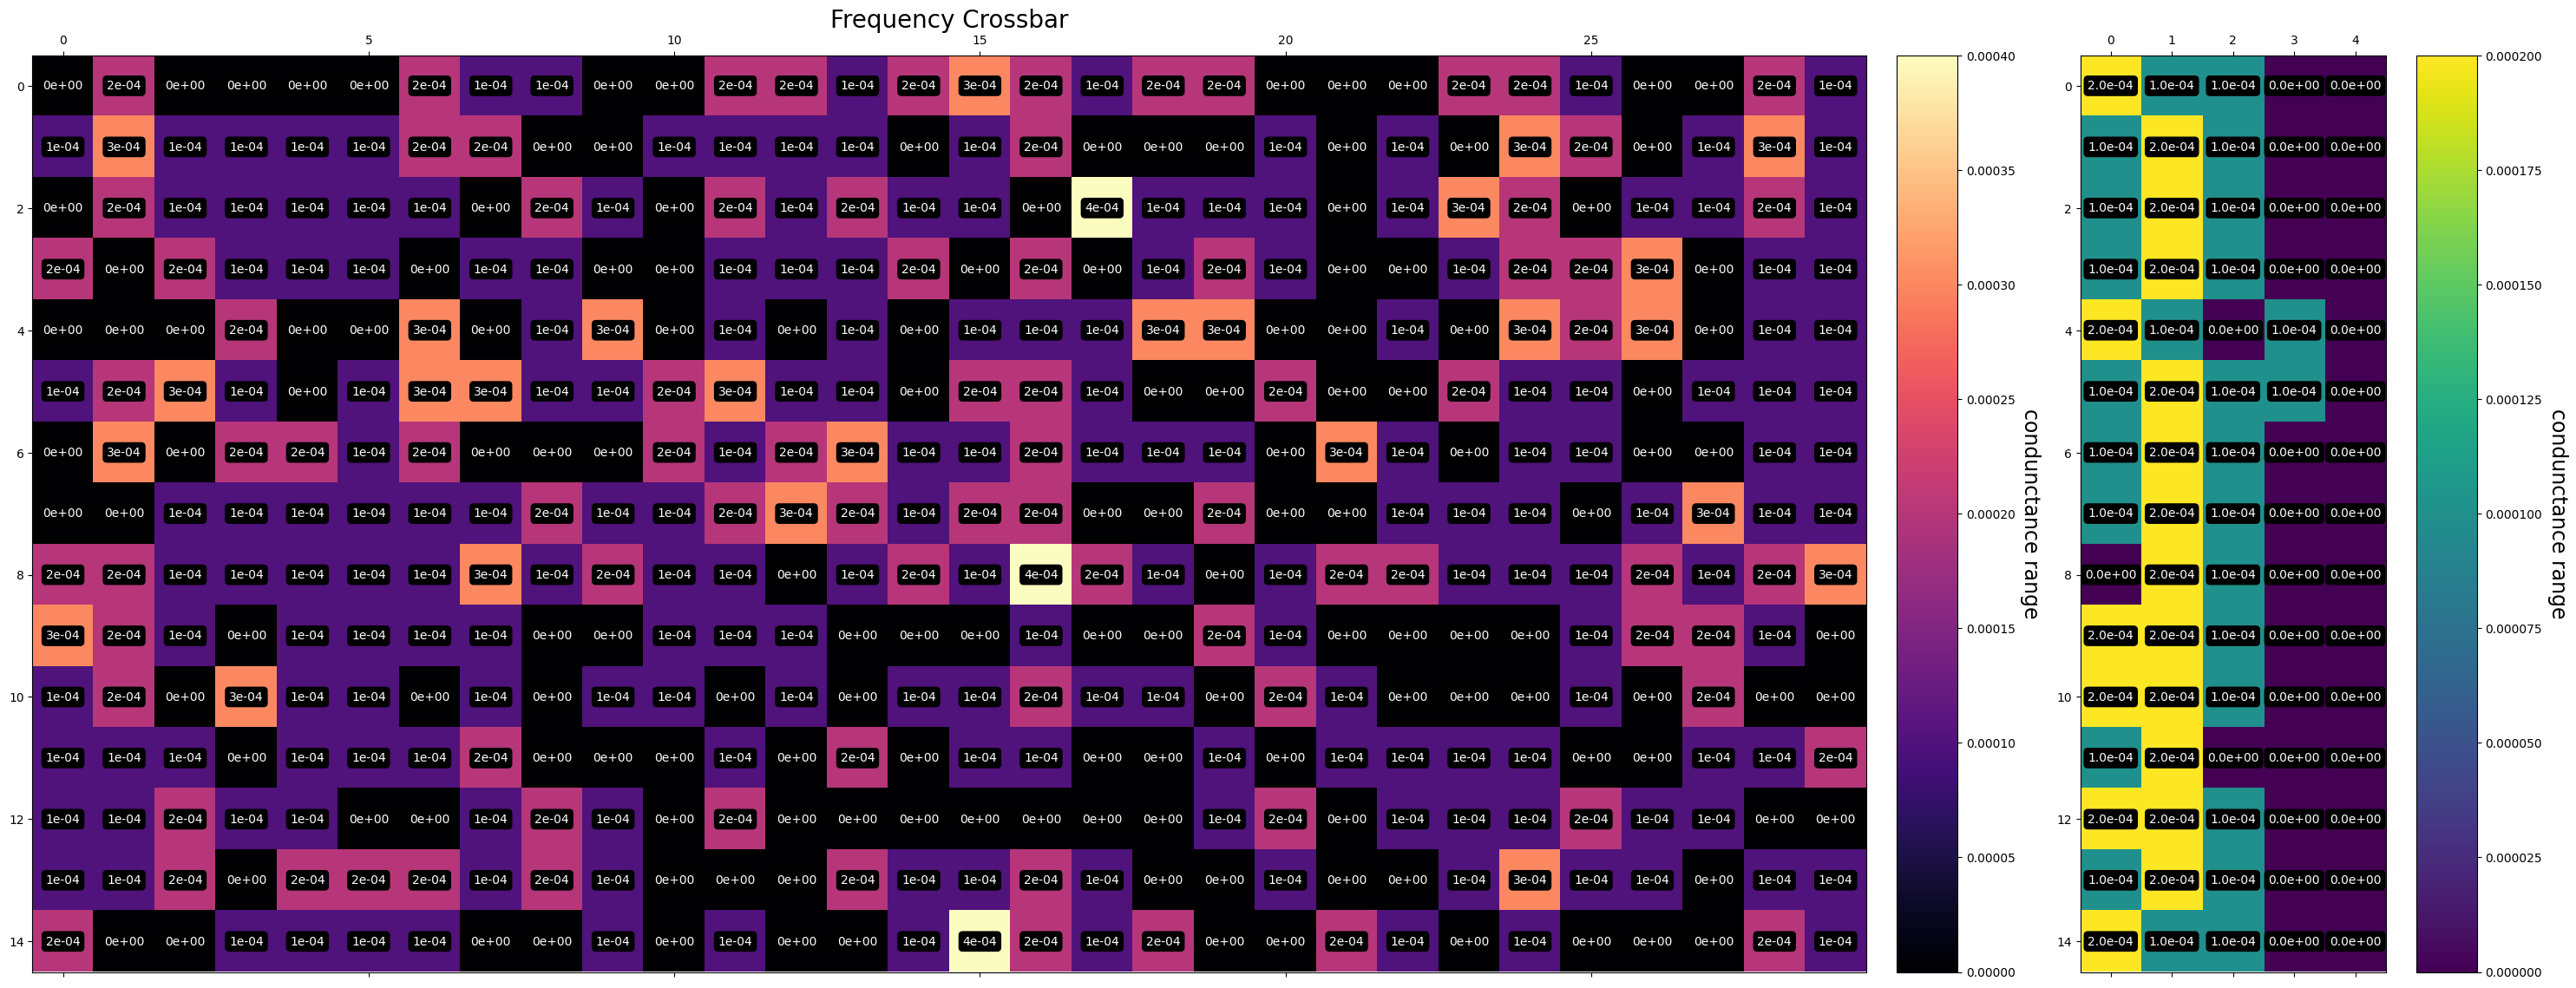

In [199]:
# plot the two crossbars as colormaps with values
import matplotlib.pyplot as plt

figsize = 1 *np.array(simple_crossbar.shape)
figsize[-1] += frequency_crossbar.shape[-1]
print(figsize)
fig, axs = plt.subplots(1, 2, figsize=figsize[::-1], gridspec_kw={'width_ratios': [simple_crossbar.shape[-1], frequency_crossbar.shape[-1]]})

im = axs[0].matshow(simple_crossbar, cmap="magma",origin='upper' )
for (i,j), z in np.ndenumerate(simple_crossbar):
    axs[0].text(j, i, '{:0.0e}'.format(z), ha='center', va='center', color='white',
        bbox=dict(boxstyle='round', facecolor='black', edgecolor='black'))
im_ratio = simple_crossbar.shape[0]/simple_crossbar.shape[1]
cax = fig.add_axes([axs[0].get_position().x1+0.01,axs[0].get_position().y0,0.02,axs[0].get_position().height])
cbar = plt.colorbar(im, cax=cax)
cbar.ax.set_ylabel("condunctance range", rotation=-90, va="bottom", fontsize=17)
axs[0].set_title("Simple Crossbar", fontsize=20)

im = axs[1].matshow(frequency_crossbar, cmap="viridis",origin='upper' )
for (i,j), z in np.ndenumerate(frequency_crossbar):
    axs[1].text(j, i, '{:0.1e}'.format(z), ha='center', va='center', color='white',
        bbox=dict(boxstyle='round', facecolor='black', edgecolor='black'))
im_ratio = frequency_crossbar.shape[0]/frequency_crossbar.shape[1]
cax = fig.add_axes([axs[1].get_position().x1+0.01,axs[1].get_position().y0,0.02,axs[1].get_position().height])
cbar = plt.colorbar(im, cax=cax)

cbar.ax.set_ylabel("condunctance range", rotation=-90, va="bottom", fontsize=17)    
axs[0].set_title("Frequency Crossbar", fontsize=20)


plt.show()

In [200]:
# define the input tensor using a normal distribution (only positive values)
inputs = np.random.normal(0,max_input/2, N)
inputs = np.clip(abs(inputs), 0, max_input)
inputs = np.zeros(N)
inputs[9:14] = 10
print("The inputs are: ",inputs)
# quantize the input voltages
bits = 4
voltages = DAC_quantizer(inputs, bits, Vdd, max_input)
print("The voltages are: ",voltages)

# compute the output currents
currents = np.zeros(M)
for i in range(M):
    currents[i] += np.dot(simple_crossbar[:,i], voltages)
    

# recompute the currents using a reference value for the voltages 
Vref = np.array([Vdd/2]*N)
currents_ref = np.zeros(M)
for i in range(M):
    currents_ref[i] += np.dot(simple_crossbar[:,i], Vref)
print("The currents are: ", currents)



The inputs are:  [ 0.  0.  0.  0.  0.  0.  0.  0.  0. 10. 10. 10. 10. 10.  0.]
The voltages are:  [0.  0.  0.  0.  0.  0.  0.  0.  0.  1.2 1.2 1.2 1.2 1.2 0. ]
The currents are:  [0.00084 0.00084 0.00072 0.00048 0.00072 0.0006  0.00048 0.00072 0.00048
 0.00036 0.00024 0.00048 0.00024 0.00048 0.00024 0.00036 0.00072 0.00024
 0.00012 0.00048 0.00072 0.00024 0.00024 0.00036 0.0006  0.0006  0.00048
 0.00072 0.00036 0.00036]


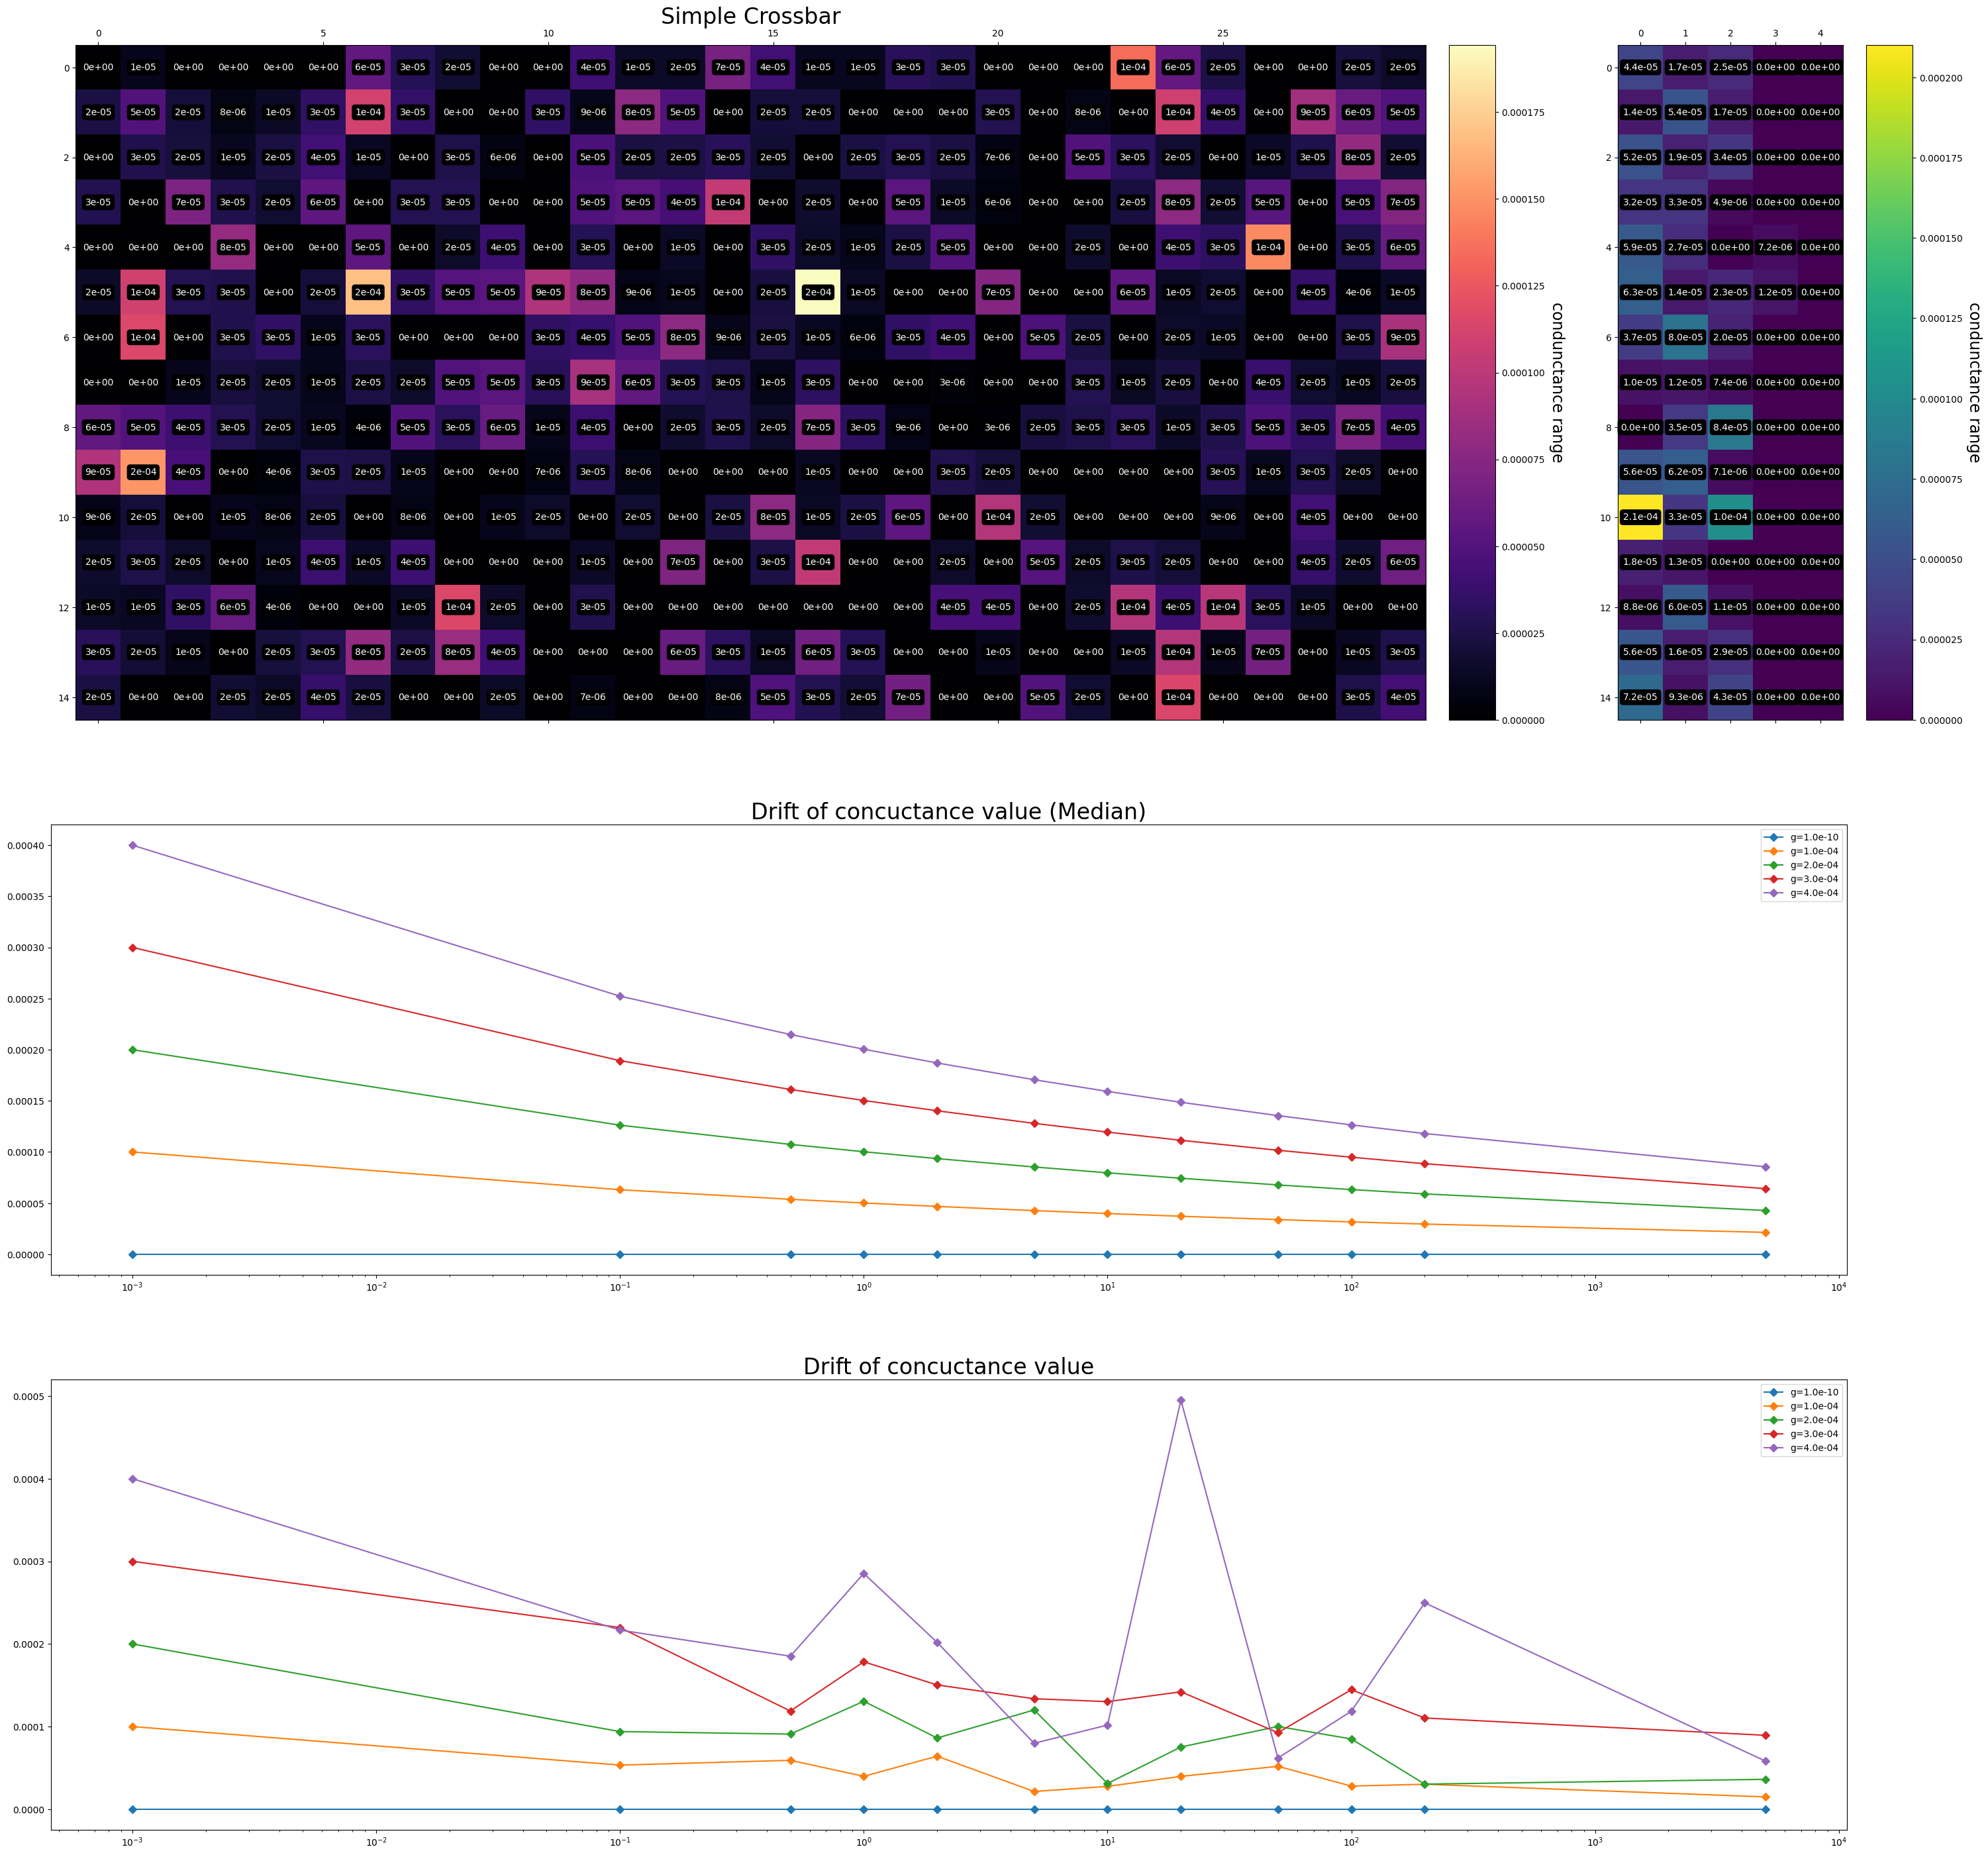

In [201]:
# Now also consider the drift of the conductances
t_values = [1e-3,0.1, 0.5, 1, 2, 5, 10, 20, 50, 100, 200,5000]
t_c = 1e-3
t = t_values[-1]

# compute the drift of the conductances
simple_crossbar_drift = np.zeros((N,M))
for i in range(N):
    for j in range(M):
        quant_ij = random.randint(0, n_levels)
        simple_crossbar_drift[i,j] = g_drift(simple_crossbar[i,j], t_c, t)

frequency_crossbar_drift = np.zeros((N,n_levels+1))
for i in range(N):
    for j in range(n_levels+1):
        frequency_crossbar_drift[i,j] = g_drift(frequency_crossbar[i,j], t_c, t)

# plot the two crossbars as colormaps with values

figsize = 1 *np.array(simple_crossbar_drift.shape)
figsize[-1] += frequency_crossbar_drift.shape[-1]
figsize[0] += 20
fig, axs = plt.subplots(3, 2, figsize=figsize[::-1], gridspec_kw={'width_ratios': [simple_crossbar_drift.shape[-1], frequency_crossbar_drift.shape[-1]],
                                                                    'height_ratios': [simple_crossbar_drift.shape[0], 10,10]  
                                                                  })

im = axs[0,0].matshow(simple_crossbar_drift, cmap="magma",origin='upper' )
for (i,j), z in np.ndenumerate(simple_crossbar_drift):
    axs[0,0].text(j, i, '{:.0e}'.format(z), ha='center', va='center', color='white',
        bbox=dict(boxstyle='round', facecolor='black', edgecolor='black'))
im_ratio = simple_crossbar_drift.shape[0]/simple_crossbar_drift.shape[1]
cax = fig.add_axes([axs[0,0].get_position().x1+0.01,axs[0,0].get_position().y0,0.02,axs[0,0].get_position().height])
cbar = plt.colorbar(im, cax=cax)
cbar.ax.set_ylabel("condunctance range", rotation=-90, va="bottom", fontsize=17)
axs[0,0].set_title("Simple Crossbar", fontsize=24)

im = axs[0,1].matshow(frequency_crossbar_drift, cmap="viridis",origin='upper' )
for (i,j), z in np.ndenumerate(frequency_crossbar_drift):
    axs[0,1].text(j, i, '{:.1e}'.format(z), ha='center', va='center', color='white',
        bbox=dict(boxstyle='round', facecolor='black', edgecolor='black'))
im_ratio = frequency_crossbar_drift.shape[0]/frequency_crossbar_drift.shape[1]
cax = fig.add_axes([axs[0,1].get_position().x1+0.01,axs[0,1].get_position().y0,0.02,axs[0,1].get_position().height])
cbar = plt.colorbar(im, cax=cax)

cbar.ax.set_ylabel("condunctance range", rotation=-90, va="bottom", fontsize=17)    
axs[1,0].set_title("Frequency Crossbar", fontsize=24)


# Plot the trend for the median drift contribution on log scale
gs = axs[1, 0].get_gridspec()
# remove the axes for the other plots
for i in range(1,3):
    for ax in axs[i,:]:
        ax.remove()
axbig1 = fig.add_subplot(gs[1,:])
axbig2 = fig.add_subplot(gs[2,:])

g_values = np.linspace(0, max_g, n_levels + 1)
g_values[0] = 0.1e-9 # avoid 0 value

# Plot the trend for the median drift contribution on log scale
for g in g_values:
    drift_values = [g_drift_median(g, t_c, t) for t in t_values]
    axbig1.plot(t_values, drift_values, label="g={:0.1e}".format(g), marker='D')

axbig1.set_xscale('log')
axbig1.legend()
axbig1.set_title("Drift of concuctance value (Median)", fontsize=24)

# Plot the trend for the drift contribution on log scale
for g in g_values:
    drift_values = [g_drift(g, t_c, t) for t in t_values]
    axbig2.plot(t_values, drift_values, label="g={:0.1e}".format(g), marker='D')

axbig2.set_xscale('log')
axbig2.legend()
axbig2.set_title("Drift of concuctance value", fontsize=24)

plt.show()


In [202]:
# Employ the IBM correction, compute the currents on the drifted crossbar usin the reference voltages
currents_drift_ref = np.zeros(M)
for i in range(M):
    currents_drift_ref[i] += np.dot(simple_crossbar_drift[:,i], Vref)
print("Currents on the drifted crossbar for reference value Vref: ", currents_drift_ref)

IBM_correction = sum(currents_drift_ref)/sum(currents_ref)
print("IBM correction factor: ", IBM_correction)

currents_drift = np.zeros(M)
for i in range(M):
    currents_drift[i] += np.dot(simple_crossbar_drift[:,i], voltages)
print("Currents on the drifted crossbar for random input voltages: ", currents_drift)

# correct the currents
currents_drift_corrected_IBM = currents_drift/IBM_correction


# extract the most significant terms in the difference
diff_sq = (currents - currents_drift_corrected_IBM)**2
indexes = np.argsort(diff_sq)
print("Indexes of the most significant terms: ", indexes[-10:])
print("Values of the most significant terms: ", diff_sq[indexes[-10:]])
# compute the error using the ideal currents and MSE
MSE = np.mean(diff_sq)
print("MSE using IBM correction: ", MSE)


Currents on the drifted crossbar for reference value Vref:  [0.00018747 0.00035445 0.00017717 0.00019302 0.00011335 0.0002026
 0.00036396 0.0001735  0.0002517  0.00017818 0.00013556 0.00029956
 0.00018625 0.00024766 0.00019569 0.00021068 0.00036079 0.00010198
 0.00018109 0.00014825 0.00017319 0.00011454 0.00012103 0.0002551
 0.00038306 0.00019185 0.00024661 0.00019465 0.00025175 0.00031362]
IBM correction factor:  0.24051361325533813
Currents on the drifted crossbar for random input voltages:  [1.97393374e-04 2.74206353e-04 1.24494495e-04 8.34968944e-05
 5.88900041e-05 1.39593812e-04 1.43784862e-04 1.16800319e-04
 2.38967017e-04 8.10712831e-05 2.70830319e-05 8.46303761e-05
 3.10516625e-05 1.58600184e-04 6.64089584e-05 1.39427650e-04
 2.32221342e-04 6.33525990e-05 6.67374100e-05 1.03612849e-04
 2.04522602e-04 8.37608929e-05 3.87993726e-05 1.62437360e-04
 1.87765888e-04 1.76738275e-04 1.32385080e-04 1.45298365e-04
 5.44476240e-05 1.08089016e-04]
Indexes of the most significant terms:  [1

In [203]:


# apply IBM correction on the weights
weights_ref = np.zeros(n_levels+1)
for i in range(n_levels+1):
    weights_ref[i] += np.dot(frequency_crossbar[:,i], Vref)
weights = np.zeros(n_levels+1)
for i in range(n_levels+1):
    weights[i] += np.dot(frequency_crossbar_drift[:,i], Vref)

IBM_correction_weights = sum(weights)/sum(weights_ref)
# print("IBM correction factor for weights: ", IBM_refined_correction_weights)
weights = np.zeros(n_levels+1)
for i in range(n_levels+1):
    weights[i] += np.dot(frequency_crossbar_drift[:,i], voltages)

# =============== IDEAL WEIGHTS ===============
# weights_ideal = np.zeros(n_levels+1)
# for i in range(n_levels+1):
#     weights_ideal[i] += np.dot(frequency_crossbar[:,i], voltages)
# weigths = weights_ideal
# =============== IDEAL WEIGHTS ===============


# Now perform the correction using the frequency crossbar
n_samples_per_level = 300
reference_tile = np.zeros((n_levels+1,n_samples_per_level))
for i in range(n_levels+1):
    reference_tile[i] = [g_drift(g_values[i], t_c, t) for j in range(n_samples_per_level)]
# compute the means for rows, then divide by the orginal g value to obtain the drift coefficients
mean_values = np.mean(reference_tile, axis=1)
print("Mean values for the drifted conductance values: ", mean_values)
drift_coefficients = mean_values/g_values
print("Drift coefficients: ", drift_coefficients)

# compute the correction factor
weights[0] = 0
w = g_values*weights
print(w)
correction_factor = np.dot(drift_coefficients, w)/np.sum(w)
print("Correction factor: ", correction_factor)

# correct the currents
currents_drift_corrected_freq = currents_drift/correction_factor

# compute the error using the ideal currents and MSE
diff_sq = (currents - currents_drift_corrected_freq)**2
indexes = np.argsort(diff_sq)
print("Indexes of the most significant terms: ", indexes[-10:])
print("Values of the most significant terms: ", diff_sq[indexes[-10:]])
# compute the error using the ideal currents and MSE
MSE = np.mean(diff_sq)
print("MSE using IBM correction: ", MSE)



Mean values for the drifted conductance values:  [2.62205876e-11 2.62235669e-05 5.25004243e-05 8.88059435e-05
 1.06570400e-04]
Drift coefficients:  [0.26220588 0.26223567 0.26250212 0.29601981 0.266426  ]
[0.00000000e+00 2.20946950e-08 3.62539072e-08 0.00000000e+00
 0.00000000e+00]
Correction factor:  0.2624012244930422
Indexes of the most significant terms:  [ 3 16 27 15  1  2 23  7  8  4]
Values of the most significant terms:  [2.61782229e-08 2.72202946e-08 2.76470621e-08 2.93618143e-08
 4.20204273e-08 6.02981083e-08 6.71027206e-08 7.55584153e-08
 1.85496654e-07 2.45592279e-07]
MSE using IBM correction:  3.229653088631298e-08


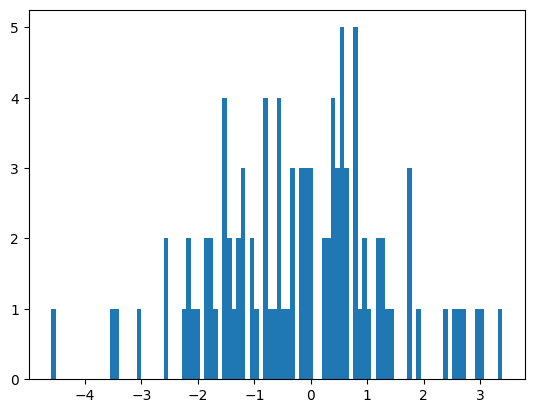

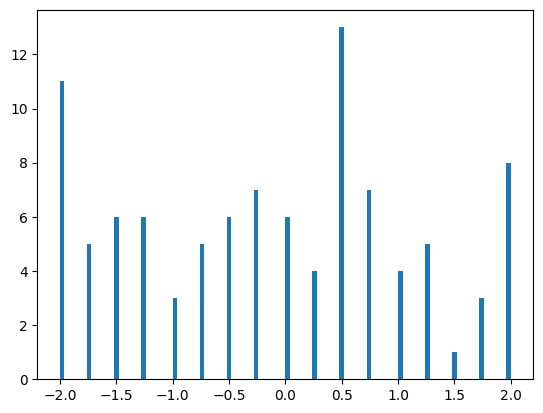

In [204]:
import numpy as np
import matplotlib.pyplot as plt

N = 100
levels = 17
amax = 2.


inputs = np.random.normal(0,1.5, N)
max_elem = np.max(inputs)

# plot histogram of the input values
plt.hist(inputs, bins=100)
plt.show()

res = (2/(levels-1))*amax

quantized_inputs = np.clip(np.round(inputs/res), -(levels-1)/2, (levels-1)/2)*res
# plot histogram of the quantized input values
plt.hist(quantized_inputs, bins=100)
plt.show()
